In [1]:
# =========================================================
# MÉTODO 6: CAUSALIDAD REZAGADA (Granger simplificado en panel)
# ¿Alguna dimensión de exclusión "precede" estadísticamente a
# otra? Ej: ¿la exclusión económica de un país predice su
# exclusión política del año siguiente, más allá de lo que la
# propia historia política ya explicaría?
#
# ACLARACIÓN METODOLÓGICA IMPORTANTE (léela antes de usar el
# resultado en el artículo): esto NO es un test de Granger
# panel propiamente dicho (ej. Dumitrescu-Hurlin), que requiere
# librerías especializadas y series más largas que las que
# tenemos (24 años). Es una versión simplificada: regresión con
# rezago de un año, con efectos fijos de país y año. Te dice
# "precedencia estadística" (X_{t-1} predice Y_t controlando por
# Y_{t-1}), no causalidad en sentido estricto. Repórtalo así.
# =========================================================

# =========================================================
# CELDA 1: Cargar librerías y preparar la base de datos
# ---------------------------------------------------------
# Objetivo:
#   - Instalar la librería `linearmodels`.
#   - Importar las librerías necesarias para el análisis.
#   - Leer la base de datos de V-Dem.
#   - Filtrar únicamente el período 2000–2023.
#
# Además:
#   Se define el conjunto de dimensiones de exclusión que
#   serán analizadas y sus nombres abreviados para facilitar
#   la interpretación de tablas y gráficos.
#
# Resultado:
#   La base de datos y las variables quedan listas para
#   construir el panel con rezagos.
# =========================================================

!pip install -q linearmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS

df = pd.read_csv('/content/vdem_exclusion_subset.csv')
df21 = df[(df['year'] >= 2000) & (df['year'] <= 2023)].copy()

exclusion_cols = ['v2xpe_exlsocgr', 'v2xpe_exlgender', 'v2xpe_exlecon', 'v2xpe_exlpol', 'v2xpe_exlgeo']
nombres_cortos = {
    'v2xpe_exlsocgr': 'Social',
    'v2xpe_exlgender': 'Género',
    'v2xpe_exlecon': 'Económica',
    'v2xpe_exlpol': 'Política',
    'v2xpe_exlgeo': 'Geográfica'
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.0 MB/s eta 0:00:00


In [2]:
# =========================================================
# CELDA 2: Construir el panel con variables rezagadas
# ---------------------------------------------------------
# Objetivo:
#   Preparar un panel longitudinal donde cada dimensión de
#   exclusión tenga su valor observado un año antes
#   (rezago de un período).
#
# Procedimiento:
#   - Ordenar las observaciones por país y año.
#   - Calcular el rezago de cada indicador.
#   - Eliminar el primer año de cada país, ya que no existe
#     información previa para construir el rezago.
#
# Resultado:
#   Se obtiene un panel balanceado listo para estimar
#   relaciones de precedencia temporal.
# =========================================================

sub = df21.dropna(subset=exclusion_cols).sort_values(['country_name', 'year']).copy()

for c in exclusion_cols:
    sub[f'{c}_lag'] = sub.groupby('country_name')[c].shift(1)

sub = sub.dropna(subset=[f'{c}_lag' for c in exclusion_cols])
sub = sub.set_index(['country_name', 'year'])

print(f"N = {len(sub)} observaciones país-año (después de perder el primer año de cada país por el rezago)")

N = 4095 observaciones país-año (después de perder el primer año de cada país por el rezago)


In [3]:
# =========================================================
# CELDA 3: Estimar la precedencia estadística entre todas
#           las dimensiones de exclusión
# ---------------------------------------------------------
# Objetivo:
#   Evaluar si el nivel pasado de una dimensión de
#   exclusión ayuda a predecir otra dimensión un año
#   después, controlando por:
#
#       • El propio pasado del outcome.
#       • Efectos fijos de país.
#       • Efectos fijos de año.
#
# Para cada combinación predictor → outcome se estiman:
#   - Coeficiente.
#   - Valor p.
#   - Significancia estadística.
#
# Resultado:
#   Se construye una tabla con todas las relaciones de
#   precedencia estadística entre dimensiones de exclusión.
# =========================================================

resultados = []

for outcome in exclusion_cols:
    for predictor in exclusion_cols:
        if outcome == predictor:
            continue
        y = sub[outcome]
        X = sub[[f'{outcome}_lag', f'{predictor}_lag']]
        modelo = PanelOLS(y, X, entity_effects=True, time_effects=True).fit(
            cov_type='clustered', cluster_entity=True
        )
        coef = modelo.params[f'{predictor}_lag']
        pval = modelo.pvalues[f'{predictor}_lag']
        resultados.append({
            'predictor': nombres_cortos[predictor],
            'outcome': nombres_cortos[outcome],
            'coef': coef,
            'pval': pval,
            'significativo': pval < 0.05
        })

resultados_df = pd.DataFrame(resultados)
print(resultados_df.sort_values('pval').round(4))

     predictor     outcome    coef    pval  significativo
1    Económica      Social  0.0620  0.0026           True
2     Política      Social  0.0350  0.0036           True
6     Política      Género  0.0359  0.0082           True
4       Social      Género  0.0490  0.0106           True
5    Económica      Género  0.0565  0.0125           True
19    Política  Geográfica  0.0217  0.0231           True
16      Social  Geográfica  0.0377  0.0258           True
18   Económica  Geográfica  0.0572  0.0262           True
8       Social   Económica  0.0274  0.0930          False
14   Económica    Política  0.0254  0.2432          False
17      Género  Geográfica  0.0185  0.2969          False
10    Política   Económica  0.0109  0.3035          False
12      Social    Política  0.0206  0.4093          False
7   Geográfica      Género  0.0129  0.4247          False
0       Género      Social  0.0100  0.5644          False
9       Género   Económica -0.0123  0.6074          False
15  Geográfica

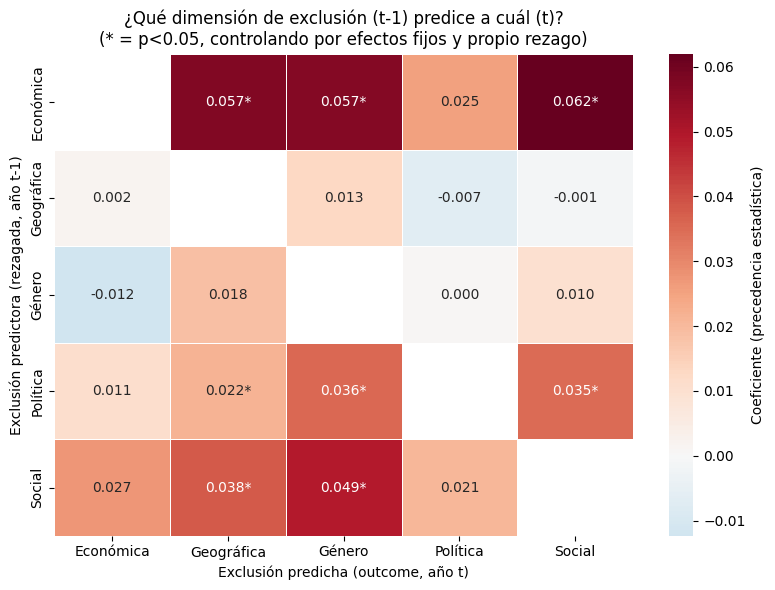

In [4]:
# =========================================================
# CELDA 4: Visualizar la matriz de precedencia
# ---------------------------------------------------------
# Objetivo:
#   Representar gráficamente las relaciones estimadas entre
#   todas las dimensiones de exclusión mediante un mapa de
#   calor (heatmap).
#
# Cada celda muestra:
#   - El coeficiente estimado.
#   - Un asterisco (*) cuando la relación es
#     estadísticamente significativa (p < 0.05).
#
# Interpretación:
#   Valores positivos indican que un mayor nivel pasado del
#   predictor se asocia con un mayor nivel futuro del
#   outcome, una vez controlados los efectos fijos y el
#   propio rezago del outcome.
# =========================================================

matriz_coef = resultados_df.pivot(index='predictor', columns='outcome', values='coef')
matriz_sig = resultados_df.pivot(index='predictor', columns='outcome', values='significativo')

# Anotación: coeficiente + asterisco si es significativo (p<0.05)
anotaciones = matriz_coef.copy().astype(str)
for i in matriz_coef.index:
    for j in matriz_coef.columns:
        if pd.isna(matriz_coef.loc[i, j]):
            anotaciones.loc[i, j] = ''
        else:
            marca = '*' if matriz_sig.loc[i, j] else ''
            anotaciones.loc[i, j] = f'{matriz_coef.loc[i,j]:.3f}{marca}'

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_coef.astype(float), annot=anotaciones, fmt='', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Coeficiente (precedencia estadística)'})
plt.title('¿Qué dimensión de exclusión (t-1) predice a cuál (t)?\n(* = p<0.05, controlando por efectos fijos y propio rezago)')
plt.xlabel('Exclusión predicha (outcome, año t)')
plt.ylabel('Exclusión predictora (rezagada, año t-1)')
plt.tight_layout()
plt.show()

In [5]:
# =========================================================
# CELDA 5: Analizar los casos de interés
# ---------------------------------------------------------
# Objetivo:
#   Extraer únicamente las relaciones que predicen las dos
#   dimensiones principales del estudio:
#
#       • Exclusión por grupos sociales.
#       • Exclusión por género.
#
# Esto facilita interpretar qué otras formas de exclusión
# parecen anteceder estadísticamente a estas dos variables.
# =========================================================

print("¿Qué precede a la exclusión SOCIAL (etnia/religión)?")
print(resultados_df[resultados_df['outcome'] == 'Social'].sort_values('pval').round(4))

print("\n¿Qué precede a la exclusión de GÉNERO?")
print(resultados_df[resultados_df['outcome'] == 'Género'].sort_values('pval').round(4))

¿Qué precede a la exclusión SOCIAL (etnia/religión)?
    predictor outcome   coef    pval  significativo
1   Económica  Social  0.062  0.0026           True
2    Política  Social  0.035  0.0036           True
0      Género  Social  0.010  0.5644          False
3  Geográfica  Social -0.001  0.9478          False

¿Qué precede a la exclusión de GÉNERO?
    predictor outcome    coef    pval  significativo
6    Política  Género  0.0359  0.0082           True
4      Social  Género  0.0490  0.0106           True
5   Económica  Género  0.0565  0.0125           True
7  Geográfica  Género  0.0129  0.4247          False


In [6]:
# =========================================================
# CELDA 6: Exportar resultados
# ---------------------------------------------------------
# Objetivo:
#   Guardar la tabla completa con todas las relaciones de
#   precedencia estadística para utilizarla posteriormente
#   en el artículo, tablas o análisis complementarios.
#
# Archivo generado:
#   - precedencia_estadistica_exclusion.csv
# =========================================================

resultados_df.to_csv('/content/precedencia_estadistica_exclusion.csv', index=False)
print("Exportado: precedencia_estadistica_exclusion.csv")

Exportado: precedencia_estadistica_exclusion.csv


In [7]:
# =========================================================
# NOTA METODOLÓGICA
# ---------------------------------------------------------
# Alcance e interpretación del análisis de precedencia
# temporal.
#
# Este procedimiento evalúa únicamente si una dimensión de
# exclusión antecede estadísticamente a otra, controlando
# por el pasado del propio outcome y por efectos fijos de
# país y año.
#
# Los resultados NO deben interpretarse como evidencia de
# causalidad, sino como posibles secuencias temporales que
# pueden orientar investigaciones posteriores con diseños
# de identificación más robustos.
# =========================================================


# --- NOTA PARA EL ARTÍCULO ---
# Un coeficiente positivo y significativo de "predictor -> outcome" dice:
# controlando por el pasado propio del outcome y por efectos fijos de
# país/año, el nivel pasado de la otra dimensión de exclusión predice un
# aumento en esta. Es evidencia de SECUENCIA, no de mecanismo causal: no
# sabemos POR QUÉ una precede a otra, solo que estadísticamente lo hace.
# Además, si una relación es significativa en ambas direcciones (A->B y
# B->A), no se puede usar como evidencia de "A causa B" - eso simplemente
# refleja que ambas dimensiones se mueven juntas en el tiempo por razones
# que este modelo no puede aislar (ej. un tercer factor no medido, como
# una crisis política general que afecta a todas las formas de exclusión
# a la vez).